# Respiratory Disease Prediction — Data Profiling
**Team:** Gowrav Lakshmipathy | Priya Dilip Bajaria | Nandini Nandan Narvekar

---

## Approach

**Phase 1 — Profile:** Inspect every dataset to understand its structure, identify issues, and make informed decisions. Do not clean anything yet.

---

## Directory Structure

```
project/
    data/
        raw/
            pm25/         daily_88101_YYYY.csv
            no2/          daily_42602_YYYY.csv
            ozone/        daily_44201_YYYY.csv
            temperature/  daily_TEMP_YYYY.csv
            humidity/     daily_RH_DP_YYYY.csv
            respiratory/  nssp_respiratory.csv
```

## Setup

In [4]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 20)

for d in ['data/processed', 'outputs/figures']:
    os.makedirs(d, exist_ok=True)

# Study period
STUDY_START = '2022-01-01'
STUDY_END   = '2025-12-31'

print('Setup complete.')
print(f'Study period: {STUDY_START} to {STUDY_END}')

Setup complete.
Study period: 2022-01-01 to 2025-12-31


---
# PHASE 1 — PROFILING

For each dataset we answer:
1. What does the raw structure look like?
2. What are the date ranges and granularity?
3. Are there missing values, and where?
4. Are there duplicates?
5. What do the value distributions look like?
6. Are there outliers that could be sensor errors vs real events?

We record all findings as comments. These findings drive the cleaning decisions in Phase 2.

In [5]:
def profile_dataset(df, name, date_col, value_cols):
    """
    Print a structured profile report for a dataframe.
    Records shape, dtypes, missing values, duplicates,
    date coverage, and value distributions.
    """
    print('=' * 65)
    print(f'PROFILE: {name}')
    print('=' * 65)

    # Basic shape
    print(f'\n[1] Shape: {df.shape[0]} rows x {df.shape[1]} columns')
    print(f'    Columns: {list(df.columns)}')

    # Dtypes
    print(f'\n[2] Data types:')
    for col, dtype in df.dtypes.items():
        print(f'    {col:<35} {dtype}')

    # Date coverage
    if date_col in df.columns:
        dates = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
        print(f'\n[3] Date range: {dates.min()} to {dates.max()}')
        print(f'    Unique dates: {dates.nunique()}')
        print(f'    Unparseable dates: {dates.isna().sum()}')

        # Check for gaps in the date sequence
        sorted_dates = dates.dropna().sort_values().unique()
        if len(sorted_dates) > 1:
            full_range = pd.date_range(sorted_dates[0], sorted_dates[-1], freq='D')
            missing_dates = full_range.difference(sorted_dates)
            print(f'    Expected days in range: {len(full_range)}')
            print(f'    Missing days in sequence: {len(missing_dates)}')
            if len(missing_dates) > 0 and len(missing_dates) <= 20:
                print(f'    Missing dates: {list(missing_dates.strftime("%Y-%m-%d"))}')
            elif len(missing_dates) > 20:
                print(f'    First 10 missing: {list(missing_dates[:10].strftime("%Y-%m-%d"))}')

    # Missing values
    print(f'\n[4] Missing values per column:')
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    for col in df.columns:
        if null_counts[col] > 0:
            print(f'    {col:<35} {null_counts[col]} ({null_pct[col]}%)')
    if null_counts.sum() == 0:
        print('    None.')

    # Duplicates
    dup_count = df.duplicated().sum()
    print(f'\n[5] Duplicate rows: {dup_count}')
    if date_col in df.columns:
        dup_dates = df[date_col].duplicated().sum()
        print(f'    Duplicate date values: {dup_dates}')

    # Value distributions
    print(f'\n[6] Value distributions (numeric columns):')
    num_cols = [c for c in value_cols if c in df.columns]
    if num_cols:
        desc = df[num_cols].describe().T
        print(desc.to_string())

    # Outlier check using IQR
    print(f'\n[7] Outlier check (values beyond 3 x IQR from median):')
    for col in num_cols:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr
        outliers = series[(series < lower) | (series > upper)]
        print(f'    {col:<35} {len(outliers)} outliers | range [{lower:.3f}, {upper:.3f}] | '
              f'actual [{series.min():.3f}, {series.max():.3f}]')

    print(f'\n[8] First 3 rows:')
    print(df.head(3).to_string())
    print()

---
## Profile 1 — PM2.5

Source: EPA AQS `daily_88101_YYYY.csv`  
Expected: One row per monitoring station per day, `Date Local` and `Arithmetic Mean` (µg/m³)

In [6]:
folder = 'data/raw/pm25'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_88101') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

pm25_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
pm25_raw.columns = [c.strip() for c in pm25_raw.columns]

# Profile the raw multi-station data first
profile_dataset(
    pm25_raw,
    name       = 'PM2.5 (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

Files found: ['daily_88101_2022.csv', 'daily_88101_2023.csv', 'daily_88101_2024.csv', 'daily_88101_2025.csv']
PROFILE: PM2.5 (raw, all stations)

[1] Shape: 2915841 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum   

In [7]:
# How many unique monitoring stations?
print(f"Unique states:    {pm25_raw['State Name'].nunique()}")
print(f"Unique counties:  {pm25_raw['County Name'].nunique() if 'County Name' in pm25_raw.columns else 'N/A'}")
print(f"Unique sites:     {pm25_raw['Site Num'].nunique() if 'Site Num' in pm25_raw.columns else 'N/A'}")

# How many stations report per day on average?
daily_station_counts = pm25_raw.groupby('Date Local').size()
print(f"\nStations reporting per day:")
print(f"  Mean:   {daily_station_counts.mean():.0f}")
print(f"  Min:    {daily_station_counts.min()}")
print(f"  Max:    {daily_station_counts.max()}")
print(f"\nDays with fewer than 100 stations reporting:")
sparse_days = daily_station_counts[daily_station_counts < 100]
print(f"  Count: {len(sparse_days)}")
if len(sparse_days) > 0:
    print(f"  Dates: {list(sparse_days.head(10).index)}")

Unique states:    54
Unique counties:  548
Unique sites:     293

Stations reporting per day:
  Mean:   2065
  Min:    6
  Max:    2875

Days with fewer than 100 stations reporting:
  Count: 12
  Dates: ['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04', '2025-11-05', '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09', '2025-11-10']


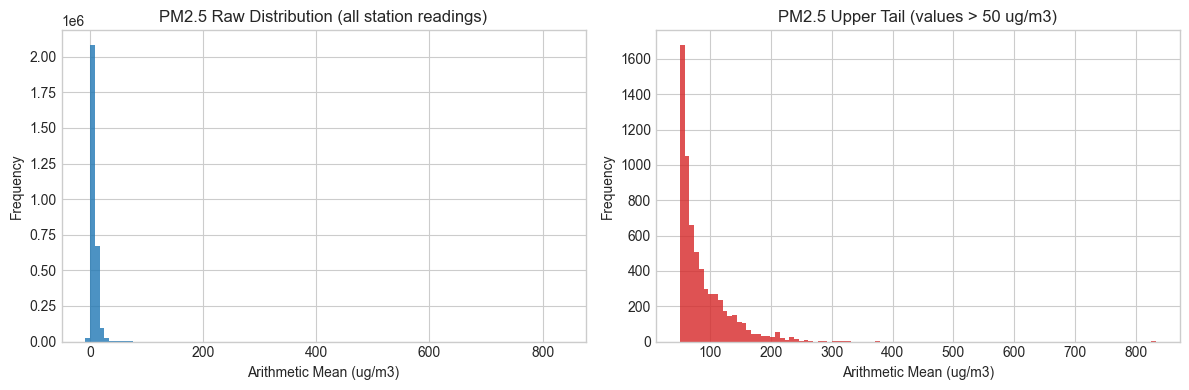

Values above 200 ug/m3 (WHO extreme threshold): 192
Values above 500 ug/m3 (likely sensor error):   2
Negative values (impossible):                   10148


In [8]:
# Visualize the Arithmetic Mean distribution to identify outlier ranges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pm25_vals = pd.to_numeric(pm25_raw['Arithmetic Mean'], errors='coerce').dropna()

axes[0].hist(pm25_vals, bins=100, color='#1f77b4', edgecolor='none', alpha=0.8)
axes[0].set_title('PM2.5 Raw Distribution (all station readings)')
axes[0].set_xlabel('Arithmetic Mean (ug/m3)')
axes[0].set_ylabel('Frequency')

# Zoom into the upper tail to see extreme values
axes[1].hist(pm25_vals[pm25_vals > 50], bins=100, color='#d62728', edgecolor='none', alpha=0.8)
axes[1].set_title('PM2.5 Upper Tail (values > 50 ug/m3)')
axes[1].set_xlabel('Arithmetic Mean (ug/m3)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/figures/profile_pm25_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Values above 200 ug/m3 (WHO extreme threshold): {(pm25_vals > 200).sum()}')
print(f'Values above 500 ug/m3 (likely sensor error):   {(pm25_vals > 500).sum()}')
print(f'Negative values (impossible):                   {(pm25_vals < 0).sum()}')

---
## Profile 2 — NO2

Source: EPA AQS `daily_42602_YYYY.csv`  
Expected: One row per monitoring station per day, `Arithmetic Mean` in ppb

In [9]:
folder = 'data/raw/no2'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_42602') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

no2_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
no2_raw.columns = [c.strip() for c in no2_raw.columns]

profile_dataset(
    no2_raw,
    name       = 'NO2 (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

no2_vals = pd.to_numeric(no2_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'Negative values (impossible for NO2):          {(no2_vals < 0).sum()}')
print(f'Values above 200 ppb (extreme):                {(no2_vals > 200).sum()}')

Files found: ['daily_42602_2022.csv', 'daily_42602_2023.csv', 'daily_42602_2024.csv', 'daily_42602_2025.csv']
PROFILE: NO2 (raw, all stations)

[1] Shape: 562605 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum      

In [10]:
no2_vals = pd.to_numeric(no2_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f"Date range: {no2_raw['Date Local'].min()} to {no2_raw['Date Local'].max()}")
print(f"Value range: {no2_vals.min():.3f} to {no2_vals.max():.3f}")
print(f"Mean: {no2_vals.mean():.3f} | Std: {no2_vals.std():.3f}")
print(f"Unique dates: {no2_raw['Date Local'].nunique()}")
print(f"\nSample Duration breakdown:")
print(no2_raw['Sample Duration'].value_counts().to_string())

Date range: 2022-01-01 to 2025-11-01
Value range: -4.579 to 64.058
Mean: 7.582 | Std: 6.653
Unique dates: 1401

Sample Duration breakdown:
Sample Duration
1 HOUR    562605


---
## Profile 3 — Ozone

Source: EPA AQS `daily_44201_YYYY.csv`  
Expected: `Arithmetic Mean` in ppm. Typical range 0.01 to 0.10 ppm. Above 0.15 is extreme.

In [11]:
folder = 'data/raw/ozone'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_44201') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

ozone_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
ozone_raw.columns = [c.strip() for c in ozone_raw.columns]

profile_dataset(
    ozone_raw,
    name       = 'Ozone (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean', 'AQI']
)

ozone_vals = pd.to_numeric(ozone_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'Negative values (impossible):                  {(ozone_vals < 0).sum()}')
print(f'Values above 0.2 ppm (extreme, likely error):  {(ozone_vals > 0.2).sum()}')

Files found: ['daily_44201_2022.csv', 'daily_44201_2023.csv', 'daily_44201_2024.csv', 'daily_44201_2025.csv']
PROFILE: Ozone (raw, all stations)

[1] Shape: 1412282 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum   

---
## Profile 4 — Temperature

Source: EPA AQS `daily_TEMP_YYYY.csv`  
Expected: `Arithmetic Mean` in degrees. Check whether it is Fahrenheit or Celsius — this varies by station and year in EPA data.

In [12]:
folder = 'data/raw/temperature'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_TEMP') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

temp_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
temp_raw.columns = [c.strip() for c in temp_raw.columns]

profile_dataset(
    temp_raw,
    name       = 'Temperature (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean']
)

# Critical check: what unit is being used?
if 'Units of Measure' in temp_raw.columns:
    print('\nUnits of Measure found in data:')
    print(temp_raw['Units of Measure'].value_counts().to_string())

temp_vals = pd.to_numeric(temp_raw['Arithmetic Mean'], errors='coerce').dropna()
print(f'\nTemperature value range: {temp_vals.min():.1f} to {temp_vals.max():.1f}')
print('Note: if range is roughly -30 to 45, likely Celsius')
print('      if range is roughly -20 to 115, likely Fahrenheit')

Files found: ['daily_TEMP_2022.csv', 'daily_TEMP_2023.csv', 'daily_TEMP_2024.csv', 'daily_TEMP_2025.csv']
PROFILE: Temperature (raw, all stations)

[1] Shape: 1184025 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                                 int64
    Latitude                            float64
    Longitude                           float64
    Datum 

In [13]:
temp_vals = pd.to_numeric(temp_raw['Arithmetic Mean'], errors='coerce')
print(temp_vals[temp_vals < -100].value_counts().head(20))
print(f'\nRows below -100F: {(temp_vals < -100).sum()}')
print(f'Rows below -459F (below absolute zero): {(temp_vals < -459.67).sum()}')

Arithmetic Mean
-1177.6708    1
Name: count, dtype: int64

Rows below -100F: 1
Rows below -459F (below absolute zero): 1


In [14]:
print(temp_vals[temp_vals > 140].value_counts().head(20))
print(f'Rows above 140F: {(temp_vals > 140).sum()}')

Arithmetic Mean
141.2333    2
152.9250    1
155.8958    1
154.0500    1
145.8792    1
150.3708    1
153.0375    1
155.6042    1
157.0500    1
159.0458    1
159.6958    1
158.3208    1
156.8000    1
154.3375    1
150.7500    1
146.7750    1
148.4000    1
143.1292    1
144.9708    1
148.2667    1
Name: count, dtype: int64
Rows above 140F: 79


---
## Profile 5 — Humidity

Source: EPA AQS `daily_RH_DP_YYYY.csv`  
Expected: Contains both Relative Humidity (%) and Dew Point. We only need RH. Check the `Parameter Name` column to confirm which rows are which.

In [15]:
folder = 'data/raw/humidity'
files  = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                 if f.startswith('daily_RH_DP') and f.endswith('.csv')])
print(f'Files found: {[os.path.basename(f) for f in files]}')

humidity_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
humidity_raw.columns = [c.strip() for c in humidity_raw.columns]

# Critical: this file contains both RH and dew point — check Parameter Name
if 'Parameter Name' in humidity_raw.columns:
    print('Parameter types in this file:')
    print(humidity_raw['Parameter Name'].value_counts().to_string())
    print()

profile_dataset(
    humidity_raw,
    name       = 'Humidity/Dew Point (raw, all stations)',
    date_col   = 'Date Local',
    value_cols = ['Arithmetic Mean']
)

# Check RH-only distribution
if 'Parameter Name' in humidity_raw.columns:
    rh_only = humidity_raw[humidity_raw['Parameter Name'].str.contains('Relative Humidity', case=False, na=False)]
    rh_vals = pd.to_numeric(rh_only['Arithmetic Mean'], errors='coerce').dropna()
    print(f'\nRelative Humidity only rows: {len(rh_only)}')
    print(f'RH range: {rh_vals.min():.1f}% to {rh_vals.max():.1f}%')
    print(f'Values above 100% (impossible): {(rh_vals > 100).sum()}')
    print(f'Values below 0% (impossible):   {(rh_vals < 0).sum()}')

Files found: ['daily_RH_DP_2022.csv', 'daily_RH_DP_2023.csv', 'daily_RH_DP_2024.csv', 'daily_RH_DP_2025.csv']
Parameter types in this file:
Parameter Name
Relative Humidity     535740
Dew Point              43518

PROFILE: Humidity/Dew Point (raw, all stations)

[1] Shape: 579258 rows x 29 columns
    Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Arithmetic Mean', '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name', 'CBSA Name', 'Date of Last Change']

[2] Data types:
    State Code                          int64
    County Code                         int64
    Site Num                            int64
    Parameter Code                      int64
    POC                               

In [16]:
rh_only = humidity_raw[humidity_raw['Parameter Name'].str.contains('Relative Humidity', case=False, na=False)]
rh_vals = pd.to_numeric(rh_only['Arithmetic Mean'], errors='coerce')
print(f'Rows below 0%: {(rh_vals < 0).sum()}')
print(rh_vals[rh_vals < 0].value_counts().head(10))

Rows below 0%: 0
Series([], Name: count, dtype: int64)


---
## Profile 6 — NSSP Respiratory

Source: CDC NSSP `nssp_respiratory.csv`  
Expected: Daily rows, one per pathogen per geography. We need ARI + United States.

In [17]:
resp_path = 'data/raw/respiratory/nssp_respiratory.csv'
resp_raw = pd.read_csv(resp_path, low_memory=False)
resp_raw.columns = [c.strip() for c in resp_raw.columns]

print(f'Raw shape: {resp_raw.shape}')
print(f'Columns: {list(resp_raw.columns)}')

# What pathogens and geographies exist?
if 'pathogen' in resp_raw.columns:
    print(f'\nPathogens:')
    print(resp_raw['pathogen'].value_counts().to_string())

if 'geography' in resp_raw.columns:
    print(f'\nGeographies (first 20):')
    print(resp_raw['geography'].value_counts().head(20).to_string())

Raw shape: (259896, 4)
Columns: ['date', 'pathogen', 'geography', 'percent_visits']

Pathogens:
pathogen
ARI          64974
COVID        64974
Influenza    64974
RSV          64974

Geographies (first 20):
geography
Alabama                 5096
Alaska                  5096
Arizona                 5096
Arkansas                5096
California              5096
Colorado                5096
Connecticut             5096
Wisconsin               5096
Delaware                5096
District of Columbia    5096
Florida                 5096
Georgia                 5096
Hawaii                  5096
Idaho                   5096
Illinois                5096
Indiana                 5096
Iowa                    5096
Kansas                  5096
Kentucky                5096
Louisiana               5096


In [19]:
print(f"Total unique geographies: {resp_raw['geography'].nunique()}")
print(resp_raw['geography'].value_counts().tail(10))

Total unique geographies: 51
geography
South Dakota     5096
Tennessee        5096
Texas            5096
United States    5096
Utah             5096
Vermont          5096
Virginia         5096
Washington       5096
West Virginia    5096
Wyoming          5096
Name: count, dtype: int64


In [20]:
national_options = resp_raw[resp_raw['geography'].str.contains('unit|nation|all|US', case=False, na=False)]['geography'].unique()
print(national_options)

<StringArray>
['Massachusetts', 'United States']
Length: 2, dtype: str


In [18]:
# Profile only the rows we will actually use: ARI + United States
resp_ari_us = resp_raw[
    (resp_raw['pathogen'].str.strip().str.upper() == 'ARI') &
    (resp_raw['geography'].str.strip().str.lower() == 'united states')
].copy()

print(f'ARI + United States rows: {len(resp_ari_us)}')

profile_dataset(
    resp_ari_us,
    name       = 'Respiratory ARI - United States (filtered)',
    date_col   = 'date',
    value_cols = ['percent_visits']
)

# Check if the percent_visits values are reasonable
pct = pd.to_numeric(resp_ari_us['percent_visits'], errors='coerce').dropna()
print(f'Values below 0 (impossible):   {(pct < 0).sum()}')
print(f'Values above 100 (impossible): {(pct > 100).sum()}')
print(f'Values above 40 (very high):   {(pct > 40).sum()}')

ARI + United States rows: 1274
PROFILE: Respiratory ARI - United States (filtered)

[1] Shape: 1274 rows x 4 columns
    Columns: ['date', 'pathogen', 'geography', 'percent_visits']

[2] Data types:
    date                                str
    pathogen                            str
    geography                           str
    percent_visits                      float64

[3] Date range: 2022-09-25 00:00:00 to 2026-03-21 00:00:00
    Unique dates: 1274
    Unparseable dates: 0
    Expected days in range: 1274
    Missing days in sequence: 0

[4] Missing values per column:
    None.

[5] Duplicate rows: 0
    Duplicate date values: 0

[6] Value distributions (numeric columns):
                   count    mean    std    min     25%     50%     75%     max
percent_visits 1274.0000 13.4747 4.0175 7.0900 10.5900 12.6000 15.7375 26.5800

[7] Outlier check (values beyond 3 x IQR from median):
    percent_visits                      0 outliers | range [-4.853, 31.180] | actual [7.090, 26.

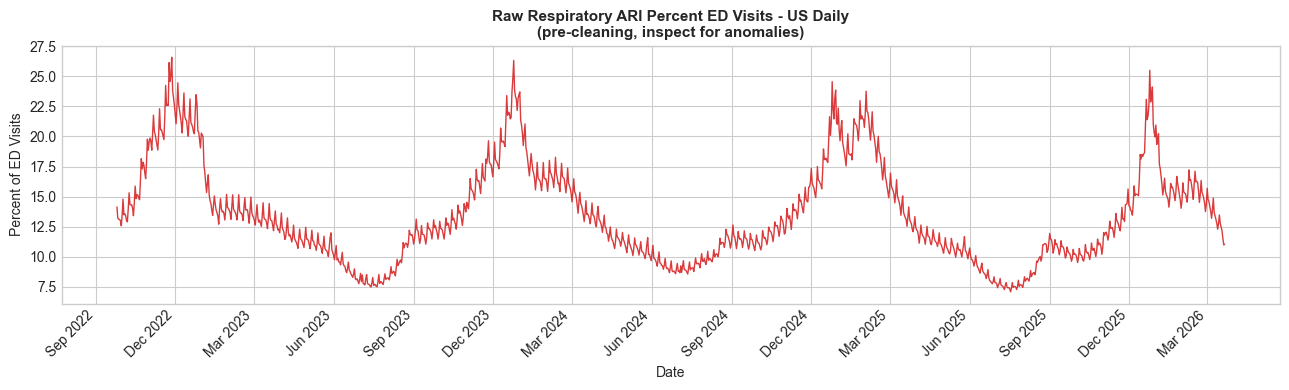

In [21]:
# Visualize the respiratory time series to check for any anomalies
resp_ari_us_sorted = resp_ari_us.copy()
resp_ari_us_sorted['date'] = pd.to_datetime(resp_ari_us_sorted['date'], format='mixed')
resp_ari_us_sorted = resp_ari_us_sorted.sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(resp_ari_us_sorted['date'], resp_ari_us_sorted['percent_visits'],
        color='#d62728', linewidth=1, alpha=0.9)
ax.set_title('Raw Respiratory ARI Percent ED Visits - US Daily\n(pre-cleaning, inspect for anomalies)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Percent of ED Visits')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/profile_respiratory_raw.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Profiling Summary

Run this cell after all profiles above. It consolidates all findings before you make cleaning decisions.

In [22]:
print('=' * 65)
print('PROFILING SUMMARY - ISSUES TO ADDRESS IN CLEANING')
print('=' * 65)
print('''
Fill in this table after running all profile cells above.
These observations will directly justify each cleaning decision.

Dataset       | Issue found                        | Planned fix
------------- | ---------------------------------- | ---------------------------
PM2.5         | [e.g. X outliers above 500 ug/m3]  | [e.g. cap at 99th pct]
PM2.5         | [e.g. mixed date formats]          | [e.g. format=mixed]
PM2.5         | [e.g. sparse reporting days]       | [e.g. flag or drop]
NO2           |                                    |
Ozone         |                                    |
Temperature   | [e.g. units = Fahrenheit or C?]    | [e.g. convert to F]
Humidity      | [e.g. contains dew point rows]     | [e.g. filter to RH only]
Respiratory   | [e.g. X missing days in sequence]  | [e.g. interpolate]
''')

PROFILING SUMMARY - ISSUES TO ADDRESS IN CLEANING

Fill in this table after running all profile cells above.
These observations will directly justify each cleaning decision.

Dataset       | Issue found                        | Planned fix
------------- | ---------------------------------- | ---------------------------
PM2.5         | [e.g. X outliers above 500 ug/m3]  | [e.g. cap at 99th pct]
PM2.5         | [e.g. mixed date formats]          | [e.g. format=mixed]
PM2.5         | [e.g. sparse reporting days]       | [e.g. flag or drop]
NO2           |                                    |
Ozone         |                                    |
Temperature   | [e.g. units = Fahrenheit or C?]    | [e.g. convert to F]
Humidity      | [e.g. contains dew point rows]     | [e.g. filter to RH only]
Respiratory   | [e.g. X missing days in sequence]  | [e.g. interpolate]

